# Titanic 데이터셋 — 딥러닝 이진 분류 실습

**데이터**: `pandas/data/titanic_train.csv`
**목표**: 승객의 생존 여부(`survived`) 예측 — **이진 분류(Binary Classification)**

## 학습 흐름

1. **데이터 탐색적 분석 (EDA)**
2. **시각화 분석**
3. **데이터 전처리**
4. **데이터 분할**
5. **딥러닝 학습 (Baseline 모델)**
6. **결과 분석**
7. **모델 개선**
8. **개선 결과 분석 및 비교**

## 이진 분류 신경망 구성 핵심

| 항목 | 설정 |
|------|------|
| 출력층 | `Dense(1, activation='sigmoid')` |
| loss | `binary_crossentropy` |
| metrics | `accuracy` |
| 평가지표 | accuracy, precision, recall, f1, AUC |

## 1. 데이터 탐색적 분석 (EDA)

데이터의 형태, 결측치, 통계적 특성을 파악합니다.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


%matplotlib inline

df = pd.read_csv('pandas/data/titanic_train.csv')
print(f'데이터 shape: {df.shape}')
df.head()

데이터 shape: (891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embark_town
0,0,3,male,22.0,1,0,7.2500,Southampton
1,1,1,female,38.0,1,0,71.2833,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Southampton
3,1,1,female,35.0,1,0,53.1000,Southampton
4,0,3,male,35.0,0,0,8.0500,Southampton


In [50]:
# 컬럼 정보
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [51]:
# 결측치 확인
print('=== 결측치 ===')
print(df.isnull().sum())
print('\n=== 통계 요약 ===')
df.describe(include='all')

=== 결측치 ===
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embark_town      2
dtype: int64

=== 통계 요약 ===


,survived,pclass,sex,age,sibsp,parch,fare,embark_town
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,NaN,male,NaN,NaN,NaN,NaN,Southampton
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN


In [52]:
# 타겟 분포 (클래스 균형 확인)
print('=== survived 분포 ===')
print(df['survived'].value_counts())
print(f'\n생존율: {df["survived"].mean():.4f}')

=== survived 분포 ===
survived
0    549
1    342
Name: count, dtype: int64

생존율: 0.3838


## 2. 시각화 분석

주요 변수와 생존 여부의 관계를 시각화합니다.

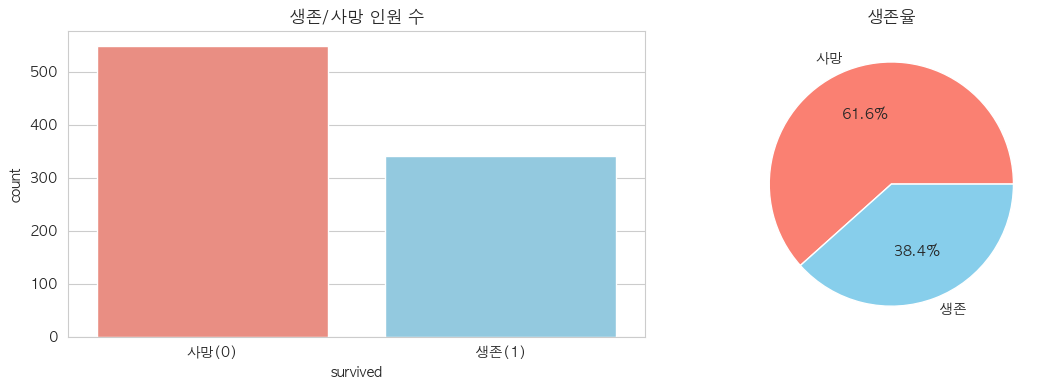

In [53]:
# 1) 생존자 수 vs 사망자 수
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='survived', ax=axes[0], palette=['salmon', 'skyblue'])
axes[0].set_title('생존/사망 인원 수')
axes[0].set_xticklabels(['사망(0)', '생존(1)'])

df['survived'].value_counts().plot.pie(
  ax=axes[1], autopct='%.1f%%', colors=['salmon', 'skyblue'],
  labels=['사망', '생존']
)
axes[1].set_ylabel('')
axes[1].set_title('생존율')

plt.tight_layout()
plt.show()

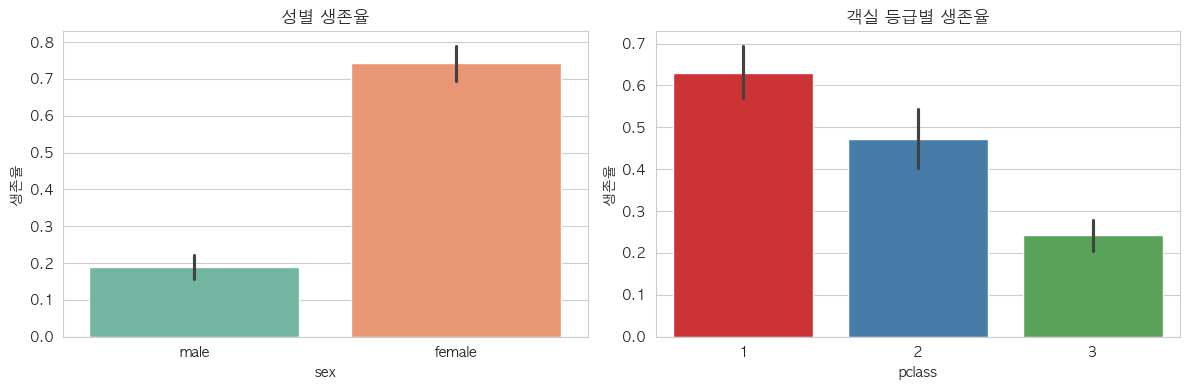

→ 여성과 1등실 승객의 생존율이 압도적으로 높음


In [54]:
# 2) 성별, 객실등급별 생존율
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df, x='sex', y='survived', ax=axes[0], palette='Set2')
axes[0].set_title('성별 생존율')
axes[0].set_ylabel('생존율')

sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], palette='Set1')
axes[1].set_title('객실 등급별 생존율')
axes[1].set_ylabel('생존율')

plt.tight_layout()
plt.show()
print('→ 여성과 1등실 승객의 생존율이 압도적으로 높음')

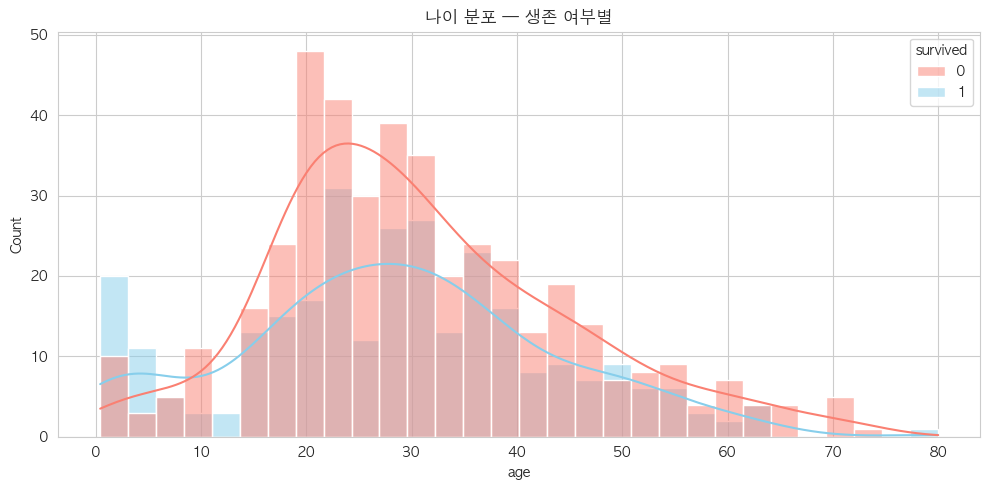

In [55]:
# 3) 나이 분포 (생존 여부별)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='survived', kde=True, bins=30, palette=['salmon', 'skyblue'])
plt.title('나이 분포 — 생존 여부별')
plt.tight_layout()
plt.show()

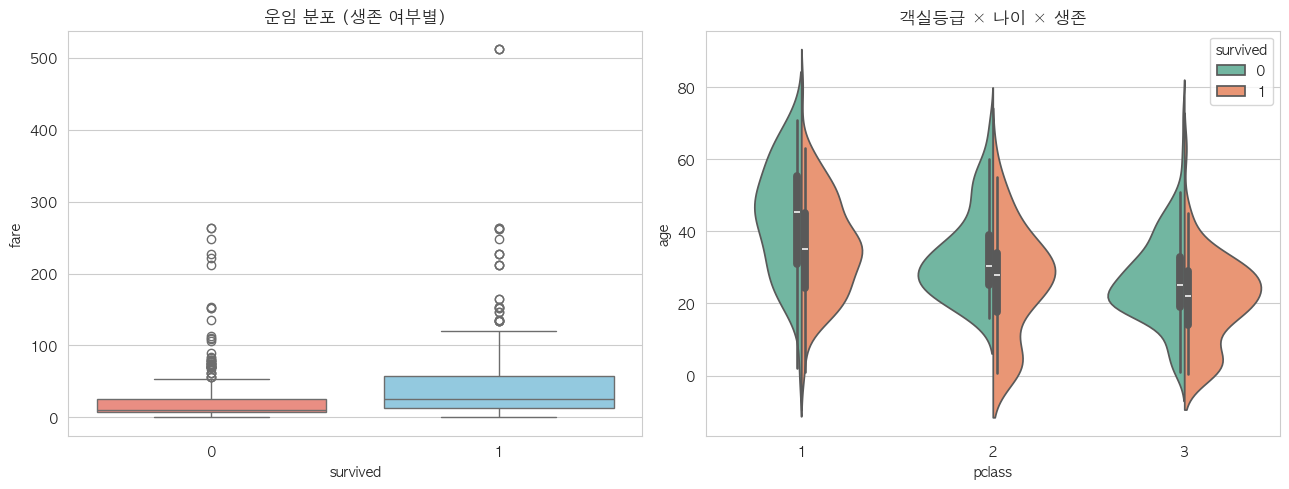

In [56]:
# 4) 운임(fare) 분포 (생존 여부별 박스플롯)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='survived', y='fare', ax=axes[0], palette=['salmon', 'skyblue'])
axes[0].set_title('운임 분포 (생존 여부별)')

sns.violinplot(data=df, x='pclass', y='age', hue='survived', split=True, ax=axes[1], palette='Set2')
axes[1].set_title('객실등급 × 나이 × 생존')

plt.tight_layout()
plt.show()

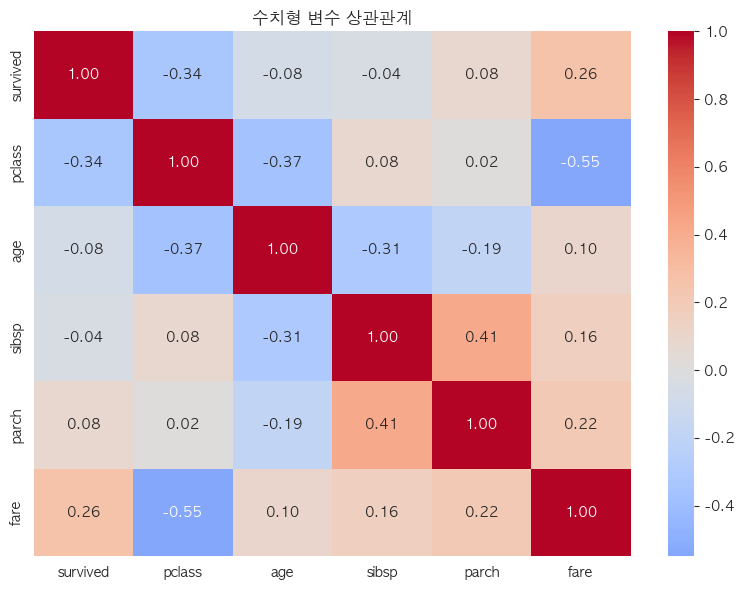

In [57]:
# 5) 수치형 변수 상관관계 히트맵
plt.figure(figsize=(8, 6))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('수치형 변수 상관관계')
plt.tight_layout()
plt.show()

## 3. 데이터 전처리

- **결측치 처리**: age는 중앙값, embark_town은 최빈값
- **범주형 인코딩**: sex, embark_town → One-Hot
- **수치형 스케일링**: StandardScaler

In [58]:
df_p = df.copy()

# 결측치 처리
df_p['age'] = df_p['age'].fillna(df_p['age'].median())
df_p['embark_town'] = df_p['embark_town'].fillna(df_p['embark_town'].mode()[0])

print(f'결측치 합계: {df_p.isnull().sum().sum()}')

결측치 합계: 0


In [59]:
# 범주형 → One-Hot Encoding
df_p = pd.get_dummies(df_p, columns=['sex', 'embark_town'], drop_first=True)

# bool → int 변환 (TensorFlow 호환)
bool_cols = df_p.select_dtypes('bool').columns
df_p[bool_cols] = df_p[bool_cols].astype(int)

print(f'전처리 후 shape: {df_p.shape}')
df_p.head()

전처리 후 shape: (891, 9)


,survived,pclass,age,sibsp,parch,fare,sex_male,embark_town_Queenstown,embark_town_Southampton
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


## 4. 데이터 분할

- Train / Test = 80 / 20
- StandardScaler로 수치형 스케일링
- `stratify`로 클래스 비율 유지

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_p.drop('survived', axis=1)
y = df_p['survived']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)
y_train = y_train.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

print(f'X_train: {X_train_s.shape}, X_test: {X_test_s.shape}')
print(f'train 생존율: {y_train.mean():.4f}, test 생존율: {y_test.mean():.4f}')

X_train: (712, 8), X_test: (179, 8)
train 생존율: 0.3834, test 생존율: 0.3855


## 5. 딥러닝 학습 — Baseline 모델

### 기본 신경망 구성
- 은닉층 2개 (Dense 32 → 16, ReLU)
- 출력층: `Dense(1, sigmoid)`
- loss: `binary_crossentropy`
- optimizer: `adam`

In [61]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

tf.random.set_seed(42)
np.random.seed(42)

input_dim = X_train_s.shape[1]

baseline = Sequential([
  layers.Dense(32, activation='relu', input_shape=(input_dim,)),
  # layers.Dense(16, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

baseline.compile(
  optimizer='adam',
  loss='binary_crossentropy',
  metrics=['accuracy']
)
baseline.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 32)                288       
                                                                 
 dense_15 (Dense)            (None, 1)                 33        
                                                                 
Total params: 321 (1.25 KB)
Trainable params: 321 (1.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [62]:
history_base = baseline.fit(
  X_train_s, y_train,
  validation_split=0.2,
  epochs=100,
  batch_size=32,
  verbose=0
)
print(f'학습 완료 (epoch={len(history_base.history["loss"])})')

학습 완료 (epoch=100)


## 6. 결과 분석 (Baseline)

- 학습 곡선 확인 (과적합 여부)
- 평가 지표 (accuracy, precision, recall, f1, AUC)
- 혼동 행렬

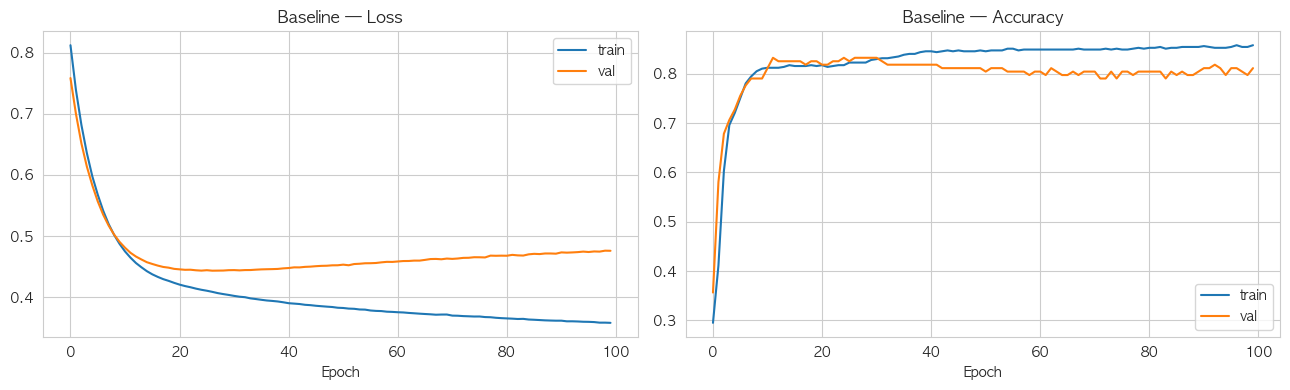

In [63]:
# 학습 곡선 함수 (재사용)
def plot_history(history, title='Learning Curve'):
  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  axes[0].plot(history.history['loss'], label='train')
  axes[0].plot(history.history['val_loss'], label='val')
  axes[0].set_title(f'{title} — Loss')
  axes[0].set_xlabel('Epoch')
  axes[0].legend()
  axes[1].plot(history.history['accuracy'], label='train')
  axes[1].plot(history.history['val_accuracy'], label='val')
  axes[1].set_title(f'{title} — Accuracy')
  axes[1].set_xlabel('Epoch')
  axes[1].legend()
  plt.tight_layout()
  plt.show()

plot_history(history_base, 'Baseline')

In [64]:
from sklearn.metrics import (
  accuracy_score, precision_score, recall_score, f1_score,
  roc_auc_score, confusion_matrix, classification_report
)

results = {}

def evaluate_clf(name, model, X_te, y_te):
  prob = model.predict(X_te, verbose=0).flatten()
  pred = (prob >= 0.5).astype(int)
  metrics = {
    'Accuracy': accuracy_score(y_te, pred),
    'Precision': precision_score(y_te, pred),
    'Recall': recall_score(y_te, pred),
    'F1': f1_score(y_te, pred),
    'AUC': roc_auc_score(y_te, prob),
  }
  results[name] = metrics
  print(f'=== [{name}] ===')
  for k, v in metrics.items():
    print(f'  {k:10s}: {v:.4f}')
  return pred, prob

pred_base, prob_base = evaluate_clf('Baseline', baseline, X_test_s, y_test)

=== [Baseline] ===
  Accuracy  : 0.7989
  Precision : 0.8367
  Recall    : 0.5942
  F1        : 0.6949
  AUC       : 0.8534


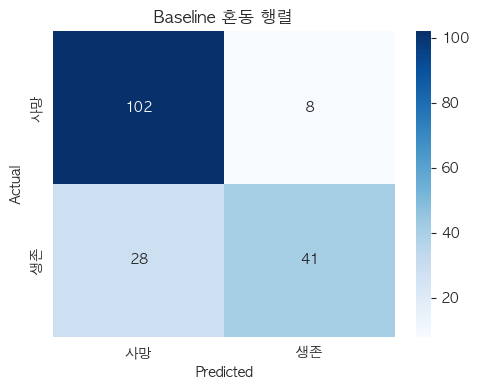

              precision    recall  f1-score   support

          사망       0.78      0.93      0.85       110
          생존       0.84      0.59      0.69        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



In [65]:
# 혼동 행렬
cm = confusion_matrix(y_test, pred_base)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['사망', '생존'], yticklabels=['사망', '생존'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Baseline 혼동 행렬')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_base, target_names=['사망', '생존']))

## 7. 모델 개선

### 개선 포인트

| 항목 | Baseline | Improved |
|------|---------|----------|
| 모델 깊이 | 32 → 16 | **64 → 32 → 16** |
| BatchNormalization | 없음 | **추가** (학습 안정화) |
| Dropout | 없음 | **추가** (과적합 방지) |
| Optimizer | adam (default) | **Adam(lr=0.001)** |
| EarlyStopping | 없음 | **추가** (best 가중치 복원) |
| ReduceLROnPlateau | 없음 | **추가** (학습률 자동 조절) |
| Class Weight | 없음 | **추가** (클래스 불균형 보정) |

In [66]:
from tensorflow.keras import callbacks, optimizers
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)
np.random.seed(42)

improved = Sequential([
  layers.Dense(64, input_shape=(input_dim,)),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  layers.Dropout(0.3),

  layers.Dense(32),
  layers.BatchNormalization(),
  layers.Activation('relu'),
  layers.Dropout(0.2),

  layers.Dense(16, activation='relu'),
  layers.Dense(1, activation='sigmoid')
])

improved.compile(
  optimizer=optimizers.Adam(learning_rate=0.001),
  loss='binary_crossentropy',
  metrics=['accuracy']
)
improved.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 64)                576       
                                                                 
 batch_normalization_4 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 activation_4 (Activation)   (None, 64)                0         
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_17 (Dense)            (None, 32)                2080      
                                                                 
 batch_normalization_5 (Bat  (None, 32)                128       
 chNormalization)                                     

In [67]:
early_stop = callbacks.EarlyStopping(
  monitor='val_loss', patience=20, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
  monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5
)

# class_weight 제거 — 사망/생존 예측의 균형을 데이터 분포 그대로 유지
# (class_weight는 recall은 올리지만 사망(다수 클래스) 정확도가 떨어짐)
history_imp = improved.fit(
  X_train_s, y_train,
  validation_split=0.2,
  epochs=300,
  batch_size=32,
  callbacks=[early_stop, reduce_lr],
  verbose=0
)
print(f'학습 완료 (epoch={len(history_imp.history["loss"])})')

학습 완료 (epoch=33)


## 8. 개선 결과 분석 및 비교

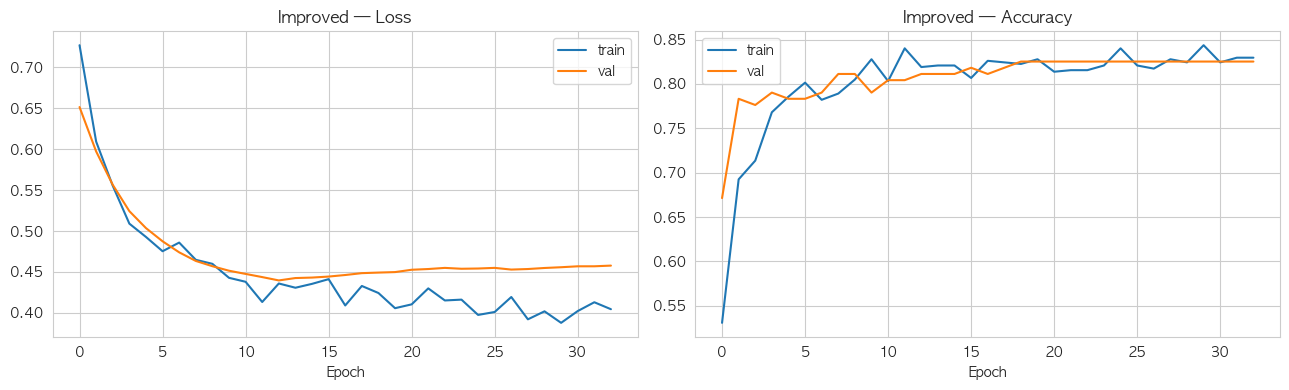

In [68]:
plot_history(history_imp, 'Improved')

In [69]:
pred_imp, prob_imp = evaluate_clf('Improved', improved, X_test_s, y_test)

=== [Improved] ===
  Accuracy  : 0.8101
  Precision : 0.8571
  Recall    : 0.6087
  F1        : 0.7119
  AUC       : 0.8484


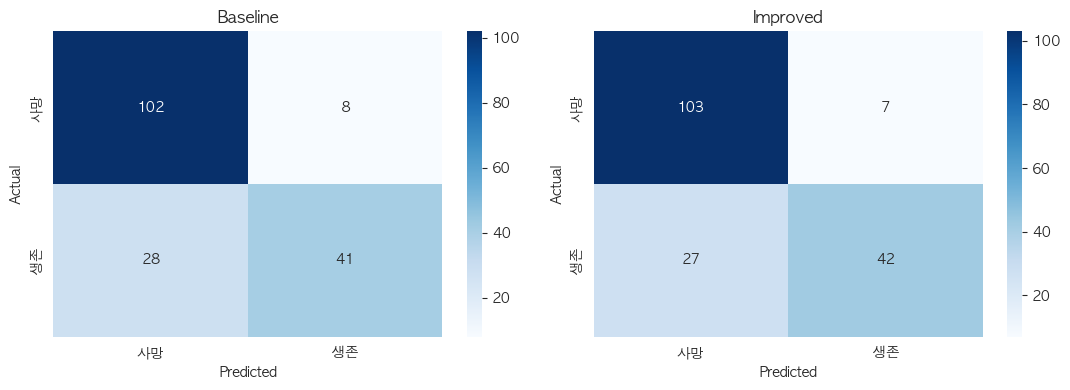

In [70]:
# 두 모델 혼동 행렬 비교
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name, pred in zip(axes, ['Baseline', 'Improved'], [pred_base, pred_imp]):
  cm = confusion_matrix(y_test, pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
              xticklabels=['사망', '생존'], yticklabels=['사망', '생존'])
  ax.set_title(f'{name}')
  ax.set_xlabel('Predicted')
  ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== 모델 성능 비교 ===
          Accuracy  Precision  Recall      F1     AUC
Baseline    0.7989     0.8367  0.5942  0.6949  0.8534
Improved    0.8101     0.8571  0.6087  0.7119  0.8484


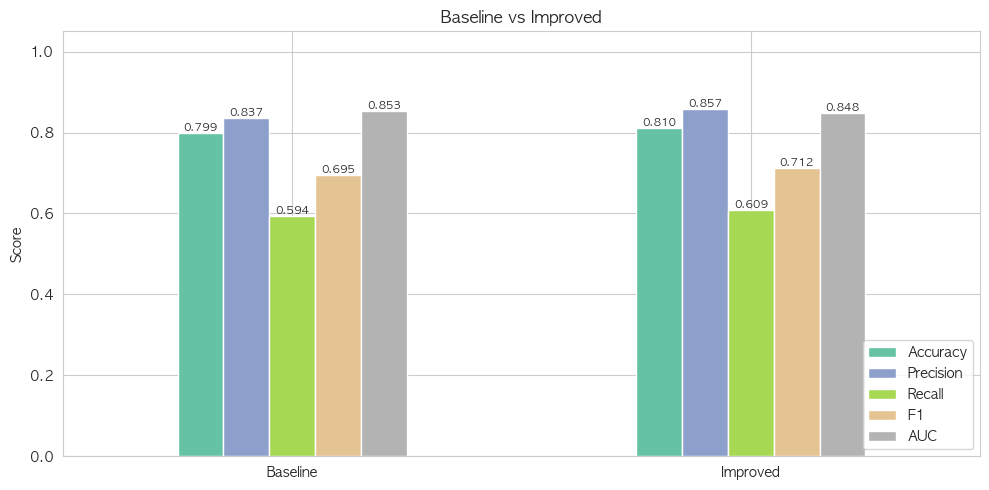

In [71]:
# 성능 비교 표 + bar chart
result_df = pd.DataFrame(results).T
print('=== 모델 성능 비교 ===')
print(result_df.round(4))

ax = result_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
ax.set_title('Baseline vs Improved')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
for c in ax.containers:
  ax.bar_label(c, fmt='%.3f', fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

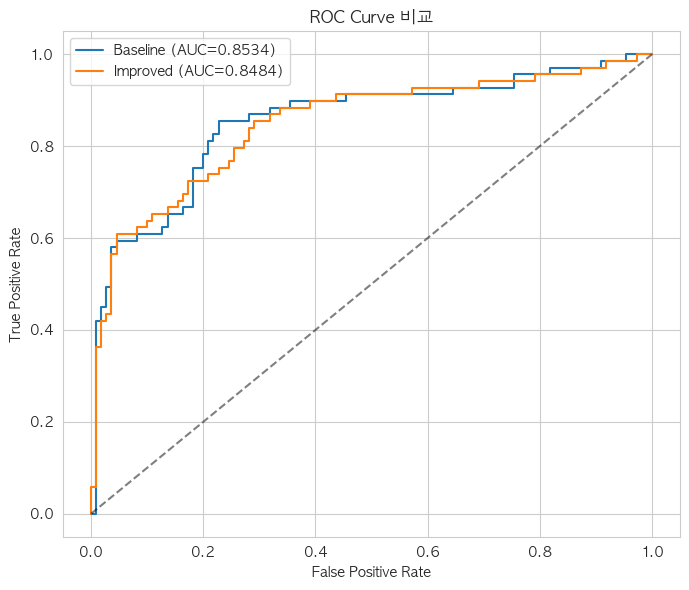

In [72]:
# ROC Curve 비교
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, prob in [('Baseline', prob_base), ('Improved', prob_imp)]:
  fpr, tpr, _ = roc_curve(y_test, prob)
  auc = roc_auc_score(y_test, prob)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve 비교')
plt.legend()
plt.tight_layout()
plt.show()

## 정리

### 개선 기법 정리

| 기법 | 목적 |
|------|------|
| **BatchNormalization** | 입력 분포 정규화로 학습 안정화/가속 |
| **Dropout** | 학습 시 일부 뉴런 제거 → 과적합 방지 |
| **EarlyStopping** | val_loss 개선 없으면 자동 중단 + best 복원 |
| **ReduceLROnPlateau** | val_loss 정체 시 학습률 자동 절반 |
| **class_weight** | 클래스 불균형 보정 (소수 클래스 가중치 ↑) |

### 핵심 포인트
- 이진 분류는 항상 **`Dense(1, sigmoid)` + `binary_crossentropy`** 조합
- accuracy 하나만 보지 말고 **precision, recall, F1, AUC**를 함께 봐야 함
- 클래스 불균형 데이터에서는 **class_weight** 또는 **oversampling**을 고려
- 학습 곡선에서 train/val gap이 크면 → **과적합** → Dropout/EarlyStopping 강화

### 시험 출제 포인트
- 출력층 활성화 함수와 loss 매칭 (sigmoid + binary_crossentropy)
- EarlyStopping 콜백 작성
- 혼동 행렬 해석 (TP/FP/TN/FN)
- ROC Curve와 AUC 의미